In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Load daily stats output from the 1k run
df = pd.read_csv('../data/outputs/1K_80bikeshareagents_seed42.csv')
df.head()

,day,bike_share,car_share,bike_count,car_count,c2b,b2c,net_switch
0,0,0.716,0.284,716,284,0,0,0
1,1,0.736,0.264,736,264,23,3,20
2,2,0.737,0.263,737,263,2,1,1
3,3,0.737,0.263,737,263,1,1,0
4,4,0.737,0.263,737,263,0,0,0


Detecting when bike share stabilizes and characterizing the tail behavior.


In [15]:
window = 7
range_threshold = 0.0015  # 0.15 percentage points

In [16]:
df = df.sort_values('day').reset_index(drop=True)

In [17]:
rolling_span = (
    df['bike_share']
    .rolling(window=window)
    .apply(lambda x: float(np.max(x) - np.min(x)), raw=True)
)

In [18]:
eq_start_day = None
for idx, span in rolling_span.items():
    if pd.notna(span) and span <= range_threshold:
        eq_start_day = int(df.loc[idx - window + 1, 'day'])
        break

In [19]:
tail_n = min(14, len(df))
tail = df.tail(tail_n)
mean_tail = tail['bike_share'].mean()
std_tail = tail['bike_share'].std(ddof=0)
min_tail = tail['bike_share'].min()
max_tail = tail['bike_share'].max()
span_tail = max_tail - min_tail
net_switch_tail = int(tail['net_switch'].sum())

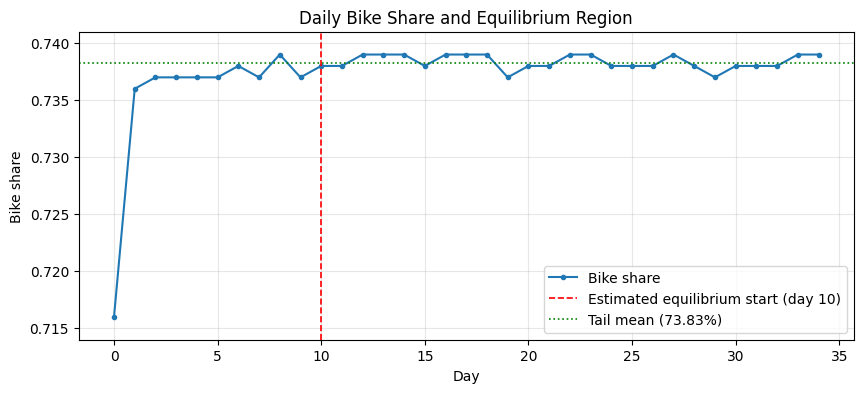

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(df['day'], df['bike_share'], marker='o', linewidth=1.5, markersize=3, label='Bike share')
if eq_start_day is not None:
    plt.axvline(eq_start_day, color='red', linestyle='--', linewidth=1.2, label=f'Estimated equilibrium start (day {eq_start_day})')
    plt.axhline(mean_tail, color='green', linestyle=':', linewidth=1.2, label=f'Tail mean ({mean_tail:.2%})')

# Auto-zoom Y axis around observed range for better visibility of small changes.
y_pad = max(0.002, span_tail * 0.8)
y_min = max(0.0, float(df['bike_share'].min()) - y_pad)
y_max = min(1.0, float(df['bike_share'].max()) + y_pad)
if y_max - y_min < 0.01:
    mid = 0.5 * (y_min + y_max)
    y_min = max(0.0, mid - 0.005)
    y_max = min(1.0, mid + 0.005)

plt.title('Daily Bike Share and Equilibrium Region')
plt.xlabel('Day')
plt.ylabel('Bike share')
plt.ylim(y_min, y_max)
plt.grid(alpha=0.3)
plt.legend()
plt.show()